## Simple Threshold Model

In [1]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix

# 1. 데이터 불러오기
df = pd.read_csv('merged_final_data.csv')

# 2. 스케일러 불러오기 (나중에 실제 수치로 역산할 때 필요할 수 있어요)
scaler = joblib.load('esc_scaler.pkl')

print(f"✅ 데이터 {len(df):,}행 로드 완료!")

✅ 데이터 272,160행 로드 완료!


In [2]:
# 예를 들어, 스케일링된 Current(전류) 값이 0.9를 넘으면 고장(1)이라고 가정해봅시다.
# (이 수치는 로프꾼님이 데이터 분포를 보고 조정해보세요!)

threshold_current = 0.9 
df['Pred_Label'] = (df['Current'] > threshold_current).astype(int)

print(f"임계치 {threshold_current} 기준으로 예측 완료!")

임계치 0.9 기준으로 예측 완료!


In [3]:
# 성능 리포트 출력
print("--- Threshold 모델 성능 평가 ---")
print(classification_report(df['Label'], df['Pred_Label']))

# 혼동 행렬 (Confusion Matrix)
print("--- Confusion Matrix ---")
print(confusion_matrix(df['Label'], df['Pred_Label']))

--- Threshold 모델 성능 평가 ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    270000
           1       0.04      0.01      0.02      2160

    accuracy                           0.99    272160
   macro avg       0.52      0.51      0.51    272160
weighted avg       0.98      0.99      0.99    272160

--- Confusion Matrix ---
[[269347    653]
 [  2133     27]]


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

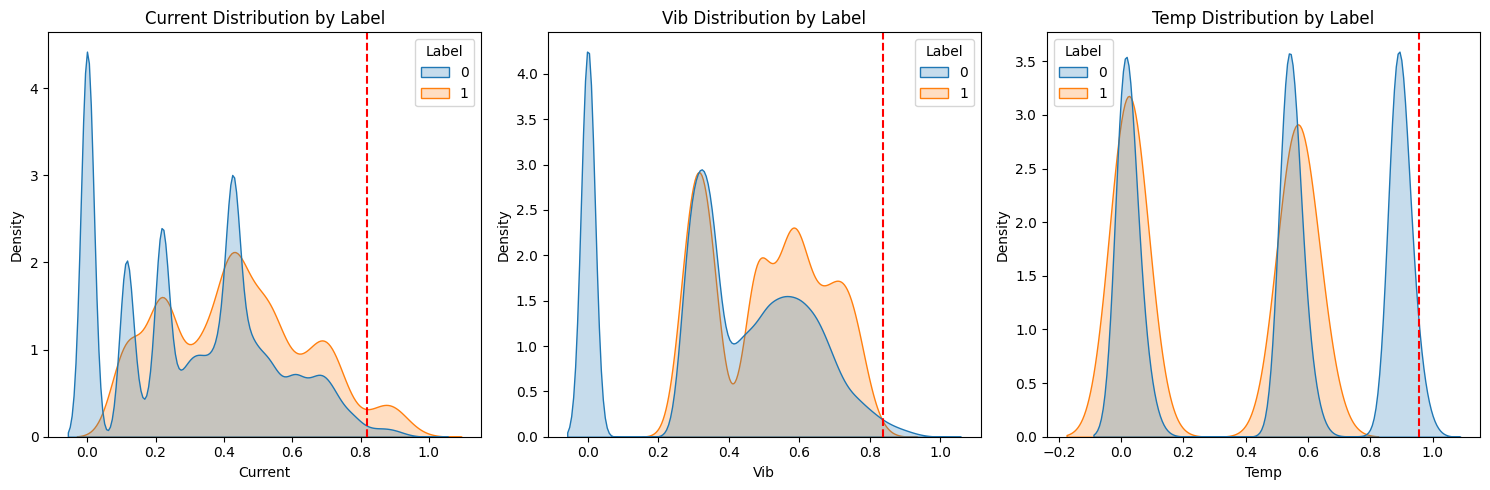

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 전류(Current)와 진동(Vib) 분포 확인
features_to_plot = ['Current', 'Vib', 'Temp']

plt.figure(figsize=(15, 5))

for i, col in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    # 실제 정답(Label)에 따른 분포 차이 시각화
    sns.kdeplot(data=df, x=col, hue='Label', fill=True, common_norm=False)
    plt.title(f'{col} Distribution by Label')
    plt.axvline(df[df['Label']==0][col].quantile(0.99), color='red', linestyle='--', label='Top 1%')

plt.tight_layout()
plt.show()

In [6]:
# 1. 역별/계절별로 정상 데이터의 '전류' 상위 1% 값을 미리 계산합니다.
# (이게 바로 각 상황에 맞는 '맞춤형 교복' 임계치가 됩니다.)
threshold_map = df[df['Label'] == 0].groupby(['Station', 'Season'])['Current'].quantile(0.99).to_dict()

# 2. 이 맵을 기준으로 예측값을 만듭니다.
def predict_threshold(row):
    # 해당 역/계절의 임계치를 가져옴
    limit = threshold_map.get((row['Station'], row['Season']))
    return 1 if row['Current'] > limit else 0

df['Pred_Label_Custom'] = df.apply(predict_threshold, axis=1)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. 성능 평가 (어제 통합 모델 성적과 비교해보세요!)
print("--- [개선된] 역별/계절별 맞춤형 Threshold 성적표 ---")
print(classification_report(df['Label'], df['Pred_Label_Custom']))

# 2. Confusion Matrix 확인
print("--- Confusion Matrix ---")
print(confusion_matrix(df['Label'], df['Pred_Label_Custom']))

'''
# 3. 태블로(Tableau) 업로드용 데이터셋 만들기
# 태블로에서 시각화하기 좋게 '성공/실패' 여부를 텍스트로 넣어주면 좋습니다.
def check_result(row):
    if row['Label'] == 1 and row['Pred_Label_Custom'] == 1: return 'TP (정답: 이상탐지)'
    if row['Label'] == 0 and row['Pred_Label_Custom'] == 0: return 'TN (정답: 정상유지)'
    if row['Label'] == 0 and row['Pred_Label_Custom'] == 1: return 'FP (오탐: 가짜알람)'
    if row['Label'] == 1 and row['Pred_Label_Custom'] == 0: return 'FN (미탐: 놓침)'
    return 'Unknown'

df['Analysis_Result'] = df.apply(check_result, axis=1)

# 4. CSV로 저장 (태블로 연결용)
df.to_csv("escalator_threshold_results.csv", index=False, encoding='utf-8-sig')
print("✅ 태블로용 결과 데이터셋 저장 완료!")
'''

--- [개선된] 역별/계절별 맞춤형 Threshold 성적표 ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    270000
           1       0.04      0.05      0.04      2160

    accuracy                           0.98    272160
   macro avg       0.52      0.52      0.52    272160
weighted avg       0.98      0.98      0.98    272160

--- Confusion Matrix ---
[[267327   2673]
 [  2052    108]]


'\n# 3. 태블로(Tableau) 업로드용 데이터셋 만들기\n# 태블로에서 시각화하기 좋게 \'성공/실패\' 여부를 텍스트로 넣어주면 좋습니다.\ndef check_result(row):\n    if row[\'Label\'] == 1 and row[\'Pred_Label_Custom\'] == 1: return \'TP (정답: 이상탐지)\'\n    if row[\'Label\'] == 0 and row[\'Pred_Label_Custom\'] == 0: return \'TN (정답: 정상유지)\'\n    if row[\'Label\'] == 0 and row[\'Pred_Label_Custom\'] == 1: return \'FP (오탐: 가짜알람)\'\n    if row[\'Label\'] == 1 and row[\'Pred_Label_Custom\'] == 0: return \'FN (미탐: 놓침)\'\n    return \'Unknown\'\n\ndf[\'Analysis_Result\'] = df.apply(check_result, axis=1)\n\n# 4. CSV로 저장 (태블로 연결용)\ndf.to_csv("escalator_threshold_results.csv", index=False, encoding=\'utf-8-sig\')\nprint("✅ 태블로용 결과 데이터셋 저장 완료!")\n'

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\workspace\test\statrack2_python\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\workspace\test\statrack2_python\

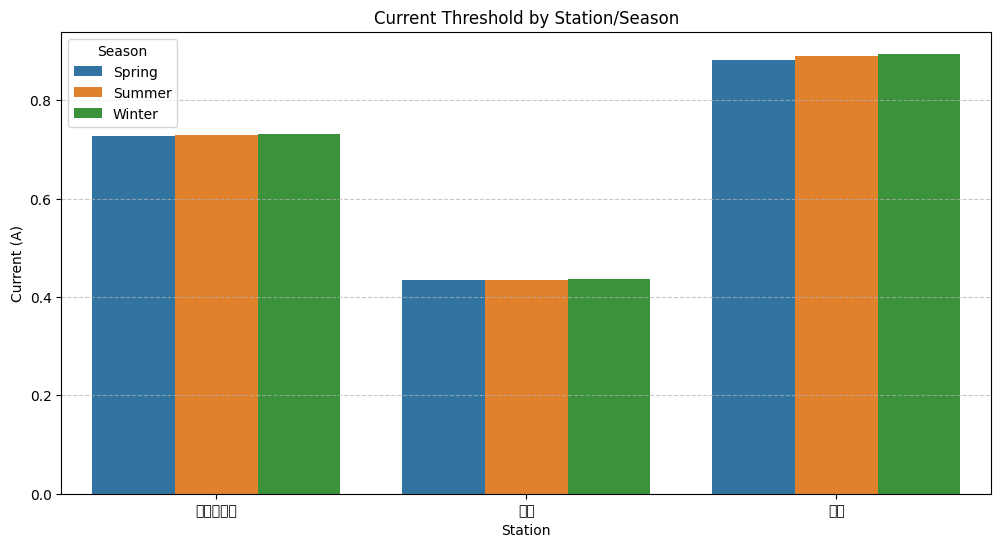

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그룹별(Station, Season) 임계치 계산 (전류 기준 상위 1%)
thresh_df = df[df['Label'] == 0].groupby(['Station', 'Season'])['Current'].quantile(0.99).reset_index()

# 2. 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=thresh_df, x='Station', y='Current', hue='Season')

plt.title('Current Threshold by Station/Season')
plt.ylabel('Current (A)')
plt.legend(title='Season')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

summary_list = []

for (station, length), group in df.groupby(['Station', 'Length']):
    # 주요 지표 계산
    precision = precision_score(group['Label'], group['Pred_Label_Custom'], zero_division=0)
    recall = recall_score(group['Label'], group['Pred_Label_Custom'], zero_division=0)
    
    # 미탐(FN)과 전체 고장 수
    total_anomalies = group['Label'].sum()
    fn_count = len(group[(group['Label'] == 1) & (group['Pred_Label_Custom'] == 0)])
    fn_rate = (fn_count / total_anomalies * 100) if total_anomalies > 0 else 0
    
    summary_list.append({
        'Station': station,
        'Length(m)': length,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'Total_Anomalies': total_anomalies,
        'Missed(FN)': fn_count,
        'Missed_Rate(%)': round(fn_rate, 1)
    })

# 결과 출력
summary_df = pd.DataFrame(summary_list)
# 미탐율(Missed_Rate)이 높은 순서대로 정렬해서 "가장 위험한 역"을 상단으로 보냅니다.
print(summary_df.sort_values(by='Missed_Rate(%)', ascending=False))

  Station  Length(m)  Precision  Recall  Total_Anomalies  Missed(FN)  \
0   고속터미널   0.000000     0.0000  0.0000              240         240   
1   고속터미널   0.333333     0.0000  0.0000              240         240   
3      용두   0.000000     0.0000  0.0000              240         240   
4      용두   0.333333     0.0000  0.0000              240         240   
6      잠실   0.000000     0.0000  0.0000              240         240   
7      잠실   0.333333     0.0000  0.0000              240         240   
5      용두   1.000000     0.0235  0.0875              240         219   
2   고속터미널   1.000000     0.0323  0.1250              240         210   
8      잠실   1.000000     0.0595  0.2375              240         183   

   Missed_Rate(%)  
0           100.0  
1           100.0  
3           100.0  
4           100.0  
6           100.0  
7           100.0  
5            91.2  
2            87.5  
8            76.2  


### standard scale으로 바꾼 데이터를 사용해서 threshold 모델 다시 구현

In [13]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# 1. 저장된 파일 불러오기
df = pd.read_csv('standard_merged.csv')

# 2. StandardScaler 데이터에 맞는 맞춤형 임계치 재계산 (Z-score 기준 상위 1%)
threshold_map_std = df[df['Label'] == 0].groupby(['Station', 'Season'])['Current'].quantile(0.99).to_dict()

def predict_std(row):
    limit = threshold_map_std.get((row['Station'], row['Season']))
    return 1 if row['Current'] > limit else 0

df['Pred_Label_Std'] = df.apply(predict_std, axis=1)

# 3. 9개 시나리오 요약 테이블 생성
summary_std = []
for (station, length), group in df.groupby(['Station', 'Length']):
    precision = precision_score(group['Label'], group['Pred_Label_Std'], zero_division=0)
    recall = recall_score(group['Label'], group['Pred_Label_Std'], zero_division=0)
    
    total_anomalies = group['Label'].sum()
    fn_count = len(group[(group['Label'] == 1) & (group['Pred_Label_Std'] == 0)])
    miss_rate = (fn_count / total_anomalies * 100) if total_anomalies > 0 else 0
    
    summary_std.append({
        'Station': station,
        'Length': length,
        'Recall': round(recall, 4),
        'Missed(FN)': fn_count,
        'Miss_Rate(%)': round(miss_rate, 1)
    })

print("==== [Standard] 시나리오별 성적 요약 ====")
print(pd.DataFrame(summary_std).sort_values(by='Miss_Rate(%)', ascending=False))

==== [Standard] 시나리오별 성적 요약 ====
  Station  Length  Recall  Missed(FN)  Miss_Rate(%)
0   고속터미널      10  0.0000         240         100.0
1   고속터미널      20  0.0000         240         100.0
3      용두      10  0.0000         240         100.0
4      용두      20  0.0000         240         100.0
6      잠실      10  0.0000         240         100.0
7      잠실      20  0.0000         240         100.0
5      용두      40  0.0875         219          91.2
2   고속터미널      40  0.1250         210          87.5
8      잠실      40  0.2375         183          76.2
